# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Rubén Gaona Pérez  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/11Am7KmpX2GcsIsfqXHN1qP9wiWudT3VH?usp=sharing <br>
Problema:
1. Sesiones de doblaje <br>

Descripción del problema:

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:

Número de actores: 10

Número de tomas : 30

Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario







                                        

# 1. Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

1.1 Espacio de soluciones

Una solución es una asignación de las 30 tomas a días de grabación. La podemos representar como un vector

solucion = [$t_1$, $t_2$, ..., $t_{30}$]

Donde cada valor indica el día en el que se hace la toma de su posición + 1. El valor de la posición 0 indicará que día se graba la toma 1.

Restricciones:
- Cada toma se asigna a exactamente un único día.
- Ningún día puede tener más de 6 tomas (el número mínimo de días posibles será 30/6 = 5 días)

In [1]:
# Matriz de participación A[toma][actor]
# 1 = el actor participa en la toma, 0 = el actor no participa en la toma

#    A1 A2 A3 A4 A5 A6 A7 A8 A9 A10
A= [[1, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # Toma 1
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],  # Toma 2
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0],  # Toma 3
    [1, 1, 0, 0, 0, 0, 1, 1, 0, 0],  # Toma 4
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0],  # Toma 5
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # Toma 6
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # Toma 7
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],  # Toma 8
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0],  # Toma 9
    [1, 1, 0, 0, 0, 1, 0, 0, 1, 0],  # Toma 10
    [1, 1, 1, 0, 1, 0, 0, 1, 0, 0],  # Toma 11
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0],  # Toma 12
    [1, 0, 0, 1, 1, 0, 0, 0, 0, 0],  # Toma 13
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0],  # Toma 14
    [1, 1, 0, 0, 0, 0, 1, 0, 0, 0],  # Toma 15
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1],  # Toma 16
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # Toma 17
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],  # Toma 18
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # Toma 19
    [1, 0, 1, 1, 1, 0, 0, 0, 0, 0],  # Toma 20
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],  # Toma 21
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],  # Toma 22
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # Toma 23
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],  # Toma 24
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 1],  # Toma 25
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 0],  # Toma 26
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],  # Toma 27
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # Toma 28
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0],  # Toma 29
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0]]  # Toma 30

N_TOMAS=len(A)       # 30
N_ACTORES=len(A[0])  # 10
MAX_TOMAS_DIA=6

1.2 Función Objetivo

El coste de un día depende de cuántos actores distintos aparecen en alguna de sus tomas (cada actor cobra un día entero independientemente de cuántas tomas haga ese día).

Definimos la matriz de participación A de dimensión 30×10, donde A[t][a] = 1 si el actor a participa en la toma t.

Para un día d, el conjunto de actores que deben asistir es la suma con OR de las filas asignadas al día d, ya que aunque un actor participe en varias tomas el mismo día, se le paga por el día, no la toma.

Por lo tanto, la función objetivo a minimizar será

$$f(sol) = \sum_{d=1}^{k} \left| \bigcup_{\{t_i \; : \; sol_{t_i} = d\}} \text{actores}(t_i) \right|$$

Donde:
- $f(sol)$ es el coste total de una solución $sol$. Lo que queremos minimizar.

- $sol$ es el vector solución. $sol = [d_1, d_2, ..., d_{30}]$ donde cada posición indica el día asignado a cada toma.

- $\sum_{d=1}^{k}$ es la suma para cada día $d$, desde el día $1$ hasta el día $k$ (número total de días usados en la solución).

- $\{t_i \; : \; sol_{t_i} = d\}$ es el conjunto de tomas asignadas al día $d$.

- $\text{actores}(t_i)$ es el conjunto de actores que participan en la toma $t_i$.

- $\bigcup$ es la unión de todos esos conjuntos de actores del día $d$ eliminando repetidos.

- $|...|$ es el número de actores distintos que hay en esa unión. Este es el coste del día $d$.


In [2]:
# Función que calcula el coste en uds de un día
def coste_dia(tomas_del_dia): # tomas_del_dia es una lista de índices de tomas asignadas a un día. Ejemplo: [0, 5, 6, 8, 12, 24]  son las tomas 1, 6, 7, 9, 13, 25
    actores=[0]*N_ACTORES # Inicialización a 0 de un vector con el mismo tamaño que el número de actores
    for t in tomas_del_dia:
        for a in range(N_ACTORES):
            if A[t][a]==1:
                actores[a]=1 # Representará si el actor trabaja ese día
    return sum(actores)

# Nos devuelve el valor de la función objetivo
def coste_total(sol):
    dias={}
    for t, d in enumerate(sol):
        dias.setdefault(d, []).append(t) # Busca la clave d, si no existe le asigna una lista vacía. El diccionario guarda como clave el 1 y el 0, y como valor las tomas que se hacen y no se hacen ese día
    return sum(coste_dia(tomas) for tomas in dias.values())

1.3  Implementación de las restricciones

Partiremos de la restricción más dura, ningún día puede tener más de 6 tomas. Al generar o modificar soluciones el operador de vecindad solo producirá movimientos válidos, comprobando primero si el día tiene menos de 6 tomas asignadas.

# 2. Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

2.1 Complejidad del problema

Nuestro problema pertenece a la clase NP-hard. Para justificarlo, lo comparamos con el Problema de la Mochila visto en clase.

Si restringimos nuestro problema a un único día de grabación, el problema se reduce a seleccionar tomas bajo una restricción de capacidad máxima (6 tomas) optimizando una función de coste, que es exactamente el Problema de la Mochila clásico. Dado que la mochila es NP-hard, y nuestro problema generaliza ese caso a múltiples días con función de coste variable (el coste de cada día depende de la combinación concreta de tomas agrupadas), nuestro problema es al menos NP-hard.

Esto implica que no existe ningún algoritmo que lo resuelva de forma exacta en tiempo polinomial, lo que justifica el uso de una metaheurística.

La complejidad de evaluar una solución tiene orden de $O(k \cdot n \cdot m)$

Donde k es el número de días, n=30 el número de tomas y m=10 el número de actores.

2.2 Espacio de soluciones

Necesitamos repartir n=30 tomas en k días con un máximo de 6 tomas por día, por lo que $k \geq \lceil 30/6 \rceil = 5$ días.

El número de formas de asignar 30 tomas a k días sin restricciones es $k^{30}$,  que usamos como cota superior del espacio de búsqueda:
- Si k = 5 días, el espacio de búsqueda $= 5^{30} = 9.3 \times 10^{20}$
- Si k = 6 días, el espacio de búsqueda $= 6^{30} = 2.2 \times 10^{23}$
- Si k = 6 días, el espacio de búsqueda $= 7^{30} = 2.2 \times 10^{25}$

Lo que quiere decir que en el mejor de los casos, el espacio de búsqueda supera los $9.3 \times 10^{20}$, lo que hace inviable aplicar un algoritmo de fuerza bruta, y refuerza la necesidad de usar un algoritmo metaheurístico.

# 3. Diseño
- ¿Que técnica utilizo? ¿Por qué?

3.1 Técnica a usar

No existe un algoritmo universalmente mejor para todos los problemas, por lo que la elección debe basarse en las características específicas del problema.

Nuestro problema tiene las siguientes características:

- Es un problema discreto.
- El espacio de soluciones tiene muchos óptimos locales.
- La función objetivo es fácil de evaluar en $O(k \cdot n \cdot m)$, lo que permite explorar muchos vecinos por iteración.

La Búsqueda Tabú es especialmente adecuada porque:

Permite escapar de óptimos locales aceptando soluciones peores cuando es necesario, algo que la búsqueda local simple no puede hacer. También evitamos ciclos ya que este algoritmo impide volver a movimientos recientes. Conseguimos equilibrar intensificación y diversificación

Es una técnica basada en trayectorias, muy adecuada para problemas discretos de asignación como el nuestro. Además, usaremos como solución inicial tanto una solución voraz como varias aleatorias.

In [3]:
import random

# Generaremos la solución inicial mediante un algoritmo voraz, que asignará las tomas en orden a cada día. Ejemplo: Dia 1 - Toma 1, 2, 3, 4, 5 y 6. Dia 2 - Las siguientes 6 tomas. Nos sirve de referencia
def solucion_voraz():
    return [t//MAX_TOMAS_DIA for t in range(N_TOMAS)] # Asigna a las 0-5 tomas (las 6 primeras), al día 0 (día 1 real), las 6-10 (6 tomas siguientes) al día 1 (día 2 real)

# Usaremos también como solución inicial una solución aleatoria, para tener un punto de inicio distinto en cada iteración, ya que haremos varias iteraciones.
def solucion_aleatoria(semilla=None):
    if semilla==None: # Si la semilla es None, cada llamada a la función solucion_aleatoria dará una solución distinta, si es distinto de None, mantendrá la reproducibilidad
        random.seed(semilla)
    tomas =list(range(N_TOMAS)) # Creamos una lista ordenada desde el 0 hasta N_TOMAS
    random.shuffle(tomas) # Se barajan las tomas de forma aleatoria
    #print(tomas)
    sol=[0]*N_TOMAS # Inicialización a 0 de un vector con el mismo tamaño que el número de tomas
    for i, t in enumerate(tomas):
        sol[t]=i//MAX_TOMAS_DIA # Aplicamos el algoritmo voraz, pero esta vez con las tomas aleatorias
    return sol


3.2 Operador de vecindad

Una solución vecina se obtiene reasignando una toma de su día actual a otro día distinto, siempre que el día destino no supere las 6 tomas. Es decir, dado $sol$, un vecino $sol'$ se obtiene eligiendo una toma $t_i$ y un día $d' \neq sol_{t_i}$ tal que se cumpla la restricción de las 6 tomas.

Búsqueda tabú múltiple
  1º Ejecución (Solución Voraz 0): Inicio = 38  -  Final = 27
  2º Ejecución (Solución aleatoria 1): Inicio = 39  -  Final = 29
  3º Ejecución (Solución aleatoria 2): Inicio = 37  -  Final = 28
  4º Ejecución (Solución aleatoria 3): Inicio = 38  -  Final = 28
  5º Ejecución (Solución aleatoria 4): Inicio = 40  -  Final = 29
  6º Ejecución (Solución aleatoria 5): Inicio = 37  -  Final = 28
  7º Ejecución (Solución aleatoria 6): Inicio = 39  -  Final = 27
  8º Ejecución (Solución aleatoria 7): Inicio = 38  -  Final = 29
  9º Ejecución (Solución aleatoria 8): Inicio = 39  -  Final = 29
  10º Ejecución (Solución aleatoria 9): Inicio = 36  -  Final = 28
  11º Ejecución (Solución aleatoria 10): Inicio = 36  -  Final = 28
  12º Ejecución (Solución aleatoria 11): Inicio = 39  -  Final = 29
  13º Ejecución (Solución aleatoria 12): Inicio = 40  -  Final = 27
  14º Ejecución (Solución aleatoria 13): Inicio = 40  -  Final = 27
  15º Ejecución (Solución aleatoria 14): Inicio 

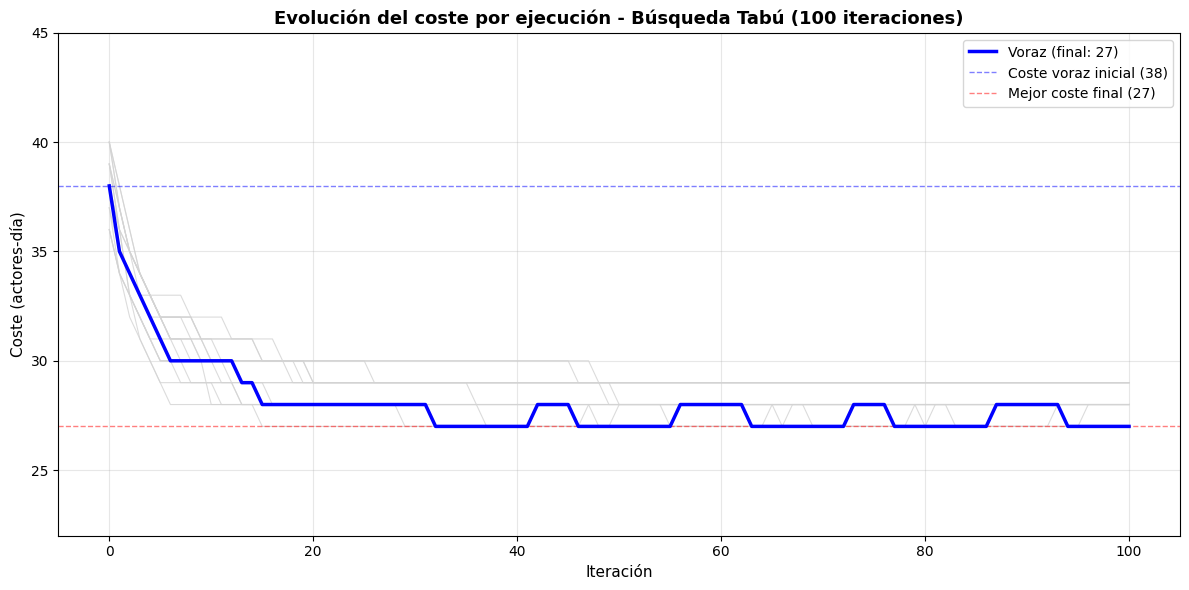

In [4]:
import matplotlib.pyplot as plt

# Función que genera vecinos a partir de una solución dada
def generar_vecinos(sol):
    conteo={} # Inicializamos un diccionario
    for d in sol:
        conteo[d]=conteo.get(d, 0) + 1 # Guardamos el número de tomas que hay asignado a cada día. Key = Día, Value = Nº tomas asignado a ese día
    dias=set(sol) # Vector con el número de días que hay en la solución actual
    vecinos=[] # lista donde iremos acumulando todas las soluciones vecinas. Cada elemento es una tupla (solucion_vecina, movimiento_realizado)

    # Movimiento 1: mover una toma a otro día con hueco (move)
    for t in range(N_TOMAS):
        d_orig=sol[t] # Día actual de la toma t
        for d_dest in dias: # d_dest es el día al que queremos mover la toma t
            if d_dest!=d_orig and conteo.get(d_dest, 0)<MAX_TOMAS_DIA: # Si el día de destino y origen no es el mismo, y si el dia de destino tiene menos de 6 tomas
                nueva_sol=sol[:] # Creamos una copia de la solución que tenemos, para no modificar el punto de partida inicial.
                nueva_sol[t]=d_dest  # Cambiamos el día en el que se realiza la toma t
                vecinos.append((nueva_sol, ('move', t, d_orig))) # Añadimos la nueva solución a la lista de vecinos, incluyendo el movimiento realizado, para no volver a repetirlo

    # Movimiento 2: intercambiar dos tomas entre días distintos (swap)
    for t1 in range(N_TOMAS): # Recorremos todas las tomas
        for t2 in range(t1+1, N_TOMAS): # Recorremos todas las tomas a partir del primer índice
            if sol[t1]!=sol[t2]: # Comprobamos que las tomas no estén en el mismo día
                nueva_sol=sol[:] # Creamos una copia de la solución que tenemos, para no modificar el punto de partida inicial.
                nueva_sol[t1]=sol[t2]
                nueva_sol[t2]=sol[t1] # Realizamos el swap
                vecinos.append((nueva_sol, ('swap', t1, t2))) # Guardamos la nueva solución y la operación hecha
    return vecinos

# Función que realiza la búsqueda tabú, le pasaremos la solución inicial con la que realizaremos la búsqueda, las iteraciones que queremos realizar y el tamaño de la lista tabú, que serán los movimientos prohibidos (para que no se repitan movimientos y volvamos a una solución anterior)
def busqueda_tabu(sol_inicial, max_iter=100, tamaño_lista_tabu=10):
    sol_actual=sol_inicial[:] # Copiamos la solución inicial
    coste_actual=coste_total(sol_actual)
    sol_mejor=sol_actual[:] # Variable donde guardaremos la mejor solución (la del mínimo coste)
    coste_mejor=coste_actual # Variable donde guardaremos el mínimo coste
    lista_tabu=[] # Lista de movimientos prohibidos, para evitar entrar en ciclos
    historial=[coste_actual] #Para registrar el coste en cada iteración

    for _ in range(max_iter): # Realizaremos max_iter iteraciones
        vecinos=generar_vecinos(sol_actual) # Generamos los vecinos de la solución actual
        if not vecinos: # Paramos y evitamos errores si no encuentra vecinos
            break

        evaluados=[] # Creamos lista vacía donde guardamos los vecinos ya evaluados en cada iteración

        for sol_vec, mov in vecinos: # Recorremos todos los vecinos generados
            c=coste_total(sol_vec) # Coste total de la solución sol_vec
            evaluados.append((c, sol_vec, mov)) # Añadimos el coste, la solución y el movimiento realizado al obetner sol_vec

        evaluados = sorted(evaluados, key=lambda x: x[0]) # Añadimos los vecinos generados y los ordenamos, usando el primer elemento (coste) para ordenar (x[0])
        sol_elegida = None # Reiniciamos la solucipón elegida
        for c, sol_vec, mov in evaluados: # Recorremos los vecinos ordenados de mejor a peor coste, ya que los hemos ordenado previamente
            clave_tabu=mov[1:] # Guardamos solamente el movimiento realizado del vecino generado
            if clave_tabu not in lista_tabu or c<coste_mejor: # Si el movimiento a realizar no esta en la lista tabú o, aunque esté, supera el mejor coste
                sol_elegida = sol_vec
                coste_elegido = c
                clave_elegida = clave_tabu
                break # Si entramos en el if, acabamos el for, ya que los demás elementos de la lista serán peores que el elegido

        if sol_elegida is None:
            break # Si no hay ningun vecino mejor, no hacer la siguiente iteración, ya que entraríamos en un bucle, generando los mismos vecinos

        sol_actual=sol_elegida # Cambiamos la solución actual a la nueva elegida
        coste_actual=coste_elegido # Cambiamos el coste actual por el nuevo elegido
        lista_tabu.append(clave_elegida) # Añadimos el movimiento realizado a la búsqueda tabú, para no repetirlo

        if len(lista_tabu)>tamaño_lista_tabu: # Añadiremos un máximo de movimientos tabú, si llegamos al máximo, eliminamos el más antiguo
            lista_tabu.pop(0)

        if coste_actual<coste_mejor: # Si el coste actual es mejor que el anteriormente mejor, el antiguo mejor es sustituido por el actual mejor
            sol_mejor=sol_actual[:]
            coste_mejor=coste_actual

        historial.append(coste_actual) # Añadimos la solución al historial de soluciones elegidas

    return sol_mejor, coste_mejor, historial # Devolvemos la mejor solución encontrada, junto con su coste y el historial completo

solucion_aleatoria()

# Función multiejecución, ya que iremos un paso más allá y no solo haremos búsqueda tabú, si no que iniciaremos el algoritmo múltiples veces con diferentes soluciones iniciales, para una mayor diversificación.
# Establecemos un número de ejecuciones, el número máximo de iteraciones y el tamaño de la lista tabú
def multiejecucion_tabu(n_ejecuciones=15):
    sol_mejor_global=None
    coste_mejor_global=float('inf') # Añadimos un valor por defecto al mejor coste, para que cualquier coste inicial sea mejor.
    historial_global=[] # Inicializamos lista vacía que servirá como historial de las soluciones que se han ido escogiendo

    print("Búsqueda tabú múltiple")

    soluciones_iniciales=[]

    # Añadimos primero la solución voraz como punto de partida
    soluciones_iniciales.append(solucion_voraz())

    # Añadimos las soluciones aleatorias con semillas 0, 1, 2, ..., n_ejecuciones-1
    for i in range(n_ejecuciones):
        soluciones_iniciales.append(solucion_aleatoria(semilla=i)) # En total tendremos 16 soluciones iniciales, 1 voraz y 15 aleatorias

    historiales=[] # Inicializamos listas vacías, donde guardaremos la información sobre los historiales de las búsquedas
    etiquetas=[] # el algoritmo usado para la solución inicial
    costes_final=[] # y el coste final de cada búsqueda tabú

    for idx, sol_ini in enumerate(soluciones_iniciales): # Recorremos cada solución inicial, obteniendo sus vecinos y viendo si mejoran o no la solución actual
        if idx==0:
            nombre="Solución Voraz" # La primera la voraz ya que es el orden en la que la hemos guardado
        else:
            nombre="Solución aleatoria"

        coste_ini=coste_total(sol_ini)
        sol, coste, historial=busqueda_tabu(sol_ini) # Obtenemos sol_mejor, coste_mejor y el historial de la solución inicial
        historiales.append(historial) # Añadimos el historial
        etiquetas.append(nombre) # Añadimos el nombre del algoritmo usado para la solución inicial
        costes_final.append(coste) #Añadimos el coste final obtenido de la búsqueda tabú
        print(f"  {idx+1}º Ejecución ({nombre} {idx}): Inicio = {coste_ini}  -  Final = {coste}")

        if coste<coste_mejor_global: # Si el coste actual es mejor que el global, sustituimos las variables
            coste_mejor_global=coste
            sol_mejor_global=sol[:]
            historial_global=historial
            idx_ganador=idx

    return sol_mejor_global, coste_mejor_global, historial_global, historiales, etiquetas, costes_final, idx_ganador


# Función para mostrar los resultados por pantalla
def mostrar_planificacion(sol, coste):
    dias={} # Inicializamos diccionario, key = día, value = lista tomas
    for t, d in enumerate(sol):
        dias.setdefault(d, []).append(t + 1)
    print("\n        Planificación óptima")

    # Recorreremos todos los días para mostrar la planificación de la solución sol
    for d in sorted(dias): # Ordenamos los días de menor a mayor
        tomas=dias[d] # Cogemos las tomas del día actual
        actores_set=set() # Para evitar duplicados

        # Recorremos la matriz A
        for t in tomas: # t número de toma de la 1-30
            for a in range(N_ACTORES): # a índice del actor 0-9
                if A[t-1][a]==1:
                    actores_set.add(a + 1) # a+1: convertimos base 0 a base 1 para mostrar en pantalla

        actores_dia=sorted(actores_set) # Ordenamos los actores que participan en el día actual de menor a mayor
        print(f"\n  Día {d+1}:")
        print(f"    Tomas   : {tomas}")
        print(f"    Actores : {actores_dia}")
        print(f"    Coste   : {len(actores_dia)}")

    print(f"  Coste total: {coste}")
    print(f"  Días totales: {len(dias)}")



if __name__=="__main__":
    sol_voraz=solucion_voraz()
    coste_voraz=coste_total(sol_voraz)
    sol_optima, coste_optimo, historial, historiales, etiquetas, costes_final, idx_ganador =multiejecucion_tabu(n_ejecuciones=15)

    mostrar_planificacion(sol_optima, coste_optimo)

    print(f"\n Resumen")
    print(f"    Coste voraz: {coste_voraz}")
    print(f"    Coste mejor búsqueda tabú: {coste_optimo}")
    print(f"    Mejora absoluta: {coste_voraz - coste_optimo} actores-día")
    print(f"    Mejora relativa: {(coste_voraz - coste_optimo)/coste_voraz*100:.1f}%")

    fig, ax=plt.subplots(figsize=(12, 6)) # Realizamos una gráfica para ver la evolución del coste

    for idx, historial in enumerate(historiales):
        if idx==0:
            # Destacamos la solución voraz con un azul
            ax.plot(historial, color='blue', linewidth=2.5,
                    label=f'Voraz (final: {costes_final[0]})', zorder=3)
        elif idx == idx_ganador:
            # Destacamos la mejor solución con un rojo
            ax.plot(historial, color='red', linewidth=2.5,
                    label=f'{etiquetas[idx]} - mejor resultado ({coste_optimo})', zorder=4)
        else:
            # Resto de ejecuciones en gris
            ax.plot(historial, color='lightgray', linewidth=0.8, alpha=0.8)

    # Líneas de referencia
    ax.axhline(y=coste_voraz, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'Coste voraz inicial ({coste_voraz})')
    ax.axhline(y=coste_optimo, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Mejor coste final ({coste_optimo})')
    iteraciones_totales=len(historiales[idx_ganador])-1 # Obtenemos las iteraciones reales, ya que el algoritmo no tiene porque alcanzar el máximo numero de iteraciones
    ax.set_title(f"Evolución del coste por ejecución - Búsqueda Tabú ({iteraciones_totales} iteraciones)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Iteración", fontsize=11)
    ax.set_ylabel("Coste (actores-día)", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(22, 45)

    plt.tight_layout()
